In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import ItalianStemmer
from nltk.corpus import gutenberg
from nltk.text import Text

In [3]:
stop_words = set(stopwords.words('italian'))

print(stop_words)

{'saremmo', 'ebbi', 'avevate', 'e', 'voi', 'ero', 'facciate', 'suoi', 'saremo', 'ci', 'staremo', 'ebbe', 'saresti', 'stessimo', 'facevo', 'sarà', 'quelle', 'farete', 'c', 'dove', 'stiamo', 'loro', 'essendo', 'avevamo', 'gli', 'avevo', 'avuta', 'negl', 'stai', 'sulle', 'quale', 'negli', 'quella', 'fu', 'fecero', 'stiano', 'ne', 'ed', 'stavamo', 'dalle', 'tutto', 'faceva', 'alla', 'avendo', 'stesse', 'avrebbe', 'per', 'perché', 'erano', 'fossi', 'se', 'foste', 'facessero', 'nostri', 'tua', 'siate', 'allo', 'fareste', 'facesti', 'sarei', 'starebbe', 'tra', 'degli', 'stetti', 'facciamo', 'nel', 'sto', 'dalla', 'queste', 'io', 'degl', 'che', 'abbiano', 'avesti', 'nelle', 'dello', 'ad', 'eravate', 'fossero', 'stavate', 'avremmo', 'avesse', 'avuto', 'all', 'dallo', 'dell', 'sarebbero', 'alle', 'eravamo', 'feci', 'nei', 'ebbero', 'facessimo', 'questo', 'sue', 'suo', 'quello', 'facciano', 'tuoi', 'con', 'dal', 'sulla', 'avranno', 'a', 'o', 'stava', 'fummo', 'eri', 'tue', 'coi', 'sui', 'mio', 'l

In [4]:
swords={'e','t','o','r','com','http','https','u','reddit','savevideo', 'comments', 'redd', 'message','download'}
eng_swords=set(stopwords.words('english'))
print(swords)
stop_words.update(swords)
stop_words.update(eng_swords)
print(stop_words)

{'redd', 'u', 'o', 'reddit', 'r', 'e', 'message', 'com', 't', 'download', 'http', 'savevideo', 'https', 'comments'}
{'you', 'the', 'so', 'from', 'saremmo', "haven't", 'e', 'ero', 'haven', 'suoi', 'staremo', 'facevo', 'yourself', 'sarà', 'quelle', 'farete', 'c', 'stiamo', 'being', "don't", 'my', 'gli', 'can', 'most', 'avuta', 'negl', 'stai', 'sulle', 't', 'quale', 'quella', 'fu', 'fecero', 'stiano', 'ne', 'those', 's', 'dalle', 'tutto', 'these', 'avendo', 'per', 'how', 'erano', 'after', 'facessero', 'nostri', 'few', 'again', 'allo', "hasn't", 'tra', 'isn', 'until', 'facciamo', 'theirs', 'nel', 'io', 'degl', 'stettero', 'abbiano', 'avesti', 'fossero', 'ad', 'eravate', 'an', 'me', 'avremmo', 'avuto', 'sarebbero', 'dallo', 'for', 'eravamo', 'feci', 'ebbero', 'hers', 'quello', 'https', "it's", 'weren', 'very', 'dal', 'each', 'a', 'o', 'fummo', 'at', 'eri', 'here', "you're", 'coi', 'sui', 'le', 'about', 'there', 'al', 'faremmo', 'stessi', 'before', 'were', 'era', 'fui', 'did', 'wouldn', 'del

In [5]:
def preprocess(raw_text):
    
    #regular expression keeping only letters 
    letters_only_text = re.sub("[^a-zA-Z]", " ", raw_text)

    # convert to lower case and split into words -> convert string into list ( 'hello world' -> ['hello', 'world'])
    words = letters_only_text.lower().split()

    cleaned_words = []
    lemmatizer = ItalianStemmer() #plug in here any other stemmer or lemmatiser you want to try out
    # remove stopwords
    for word in words:
        if word not in stop_words:
            cleaned_words.append(word)
    
    # stemm or lemmatise words
    stemmed_words = []
    for word in cleaned_words:
#        word = lemmatizer.stem(word)   #dont forget to change stem to lemmatize if you are using a lemmatizer
        stemmed_words.append(word)
    
    # converting list back to string
    return " ".join(stemmed_words)

In [6]:
df=pd.read_csv('raw_data/comments.csv')
df

,subreddit,id,submission_id,body,created_utc,parent_id,permalink
0,litigi,iyeai79,z7948j,ma vai a fanculk,1669836435,t3_z7948j,/r/litigi/comments/z7948j/rant_contro_chi_non_...
1,litigi,iyeorr3,z7948j,Ci *vissero\n\nMettiti in contatto con limnee,1669841899,t3_z7948j,/r/litigi/comments/z7948j/rant_contro_chi_non_...
2,litigi,iyet2mc,z7948j,[deleted],1669843543,t1_iyeorr3,/r/litigi/comments/z7948j/rant_contro_chi_non_...
3,litigi,iyf8lcx,z7948j,"Sonder, sonder...sempre a giustificarti...\n\n...",1669850040,t1_iyet2mc,/r/litigi/comments/z7948j/rant_contro_chi_non_...
4,litigi,iycup9g,z6nbmi,Breve recensione sul portachiavi a serramanico...,1669815212,t3_z6nbmi,/r/litigi/comments/z6nbmi/ammucchiata_automati...
...,...,...,...,...,...,...,...
52803,litigi,hbxkeos,pja1kr,Temo di sì.\nNon ho mai voluto entrare su alcu...,1631023370,t1_hbxjqx0,/r/litigi/comments/pja1kr/parathread_inkproof_...
52804,litigi,hbwk9bn,pja1kr,no questo mai sentito prima,1630997742,t1_hbwk4ti,/r/litigi/comments/pja1kr/parathread_inkproof_...
52805,litigi,hbxm1rl,pja1kr,Benvenuto su r/litigi il sub di riferimento pe...,1631024111,t1_hbxkeos,/r/litigi/comments/pja1kr/parathread_inkproof_...
52806,litigi,hcjhbqo,pja1kr,> e tuttora non ci sono.\n\nho una brutta not...,1631435339,t1_hbxkeos,/r/litigi/comments/pja1kr/parathread_inkproof_...


In [8]:
comment_bodies=df.body.values.tolist()
#print(comment_bodies)

In [9]:
text='\n'.join(comment_bodies)

In [ ]:
prova= preprocess(text)


In [12]:
word_tokens = word_tokenize(prova)
filtered_sentence = [w for w in word_tokens]

In [13]:
asd= word_tokenize(text)


KeyboardInterrupt: 

In [ ]:
aa=Text(filtered_sentence)

In [ ]:
aa.concordance_list("puledra", width=10)

In [14]:
from nltk import FreqDist

In [15]:
frequency_distribution = FreqDist(filtered_sentence)
print(frequency_distribution)

<FreqDist with 69912 samples and 632052 outcomes>


In [16]:
frequency_distribution.most_common(100)

[('n', 25909),
 ('deleted', 8245),
 ('pi', 4706),
 ('perch', 3589),
 ('solo', 3209),
 ('cazzo', 3051),
 ('fare', 2556),
 ('cosa', 2363),
 ('poi', 2341),
 ('essere', 2290),
 ('fatto', 2190),
 ('te', 2130),
 ('fa', 2063),
 ('quando', 1931),
 ('cos', 1875),
 ('anni', 1859),
 ('sempre', 1636),
 ('mai', 1621),
 ('www', 1418),
 ('molto', 1405),
 ('bene', 1395),
 ('gi', 1387),
 ('quindi', 1371),
 ('prima', 1354),
 ('comunque', 1334),
 ('senza', 1324),
 ('altro', 1279),
 ('stato', 1263),
 ('ora', 1206),
 ('dire', 1201),
 ('litigi', 1178),
 ('merda', 1168),
 ('due', 1151),
 ('proprio', 1132),
 ('vita', 1100),
 ('po', 1060),
 ('ancora', 1056),
 ('pure', 1046),
 ('pu', 1043),
 ('ogni', 1036),
 ('parte', 1026),
 ('altri', 1005),
 ('gente', 993),
 ('cose', 985),
 ('va', 978),
 ('meno', 960),
 ('qualche', 948),
 ('dopo', 913),
 ('meglio', 903),
 ('invece', 902),
 ('casa', 896),
 ('italia', 875),
 ('persone', 862),
 ('tipo', 858),
 ('tanto', 854),
 ('tempo', 848),
 ('culo', 816),
 ('puoi', 811),
 ('c

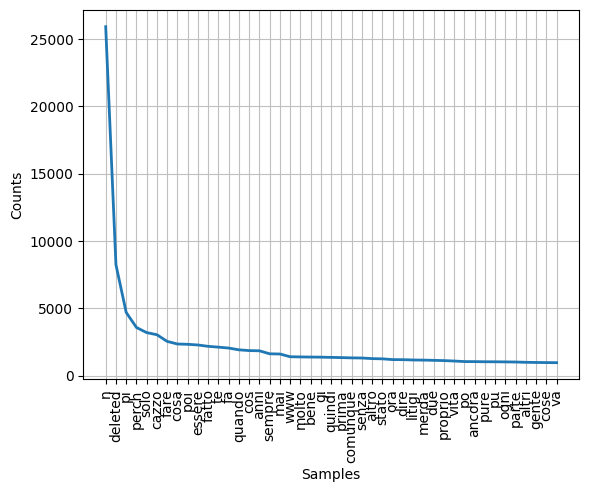

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [17]:
frequency_distribution.plot(45, cumulative=False)